In [7]:
from plotting_util import rename_random,extract_seed,rename_linear_coder,rename_estimator,rename_model,extract_k, get_sort_type, facility_location_hotfix, vectorized_replace_k, rename_explanation_type


In [18]:
import pandas as pd
linear_coder = "MSEProjUSimp"
df = pd.read_parquet("./results/scoring/merged.parquet")
df["NMSE"] = 1.0 / (df["pred_gain"] + 1e-20)
# assert (df.groupby(["explanation_type", "linear_coder"]).count() == n_test).all().all()


In [22]:

# Apply to dataframe
df["k"] = df["explanation_type"].apply(extract_k)


df["explanation_type_no_k"] = vectorized_replace_k(df["explanation_type"], df["k"])


def facility_location_hotfix(x):
    if ("facility" in x) and x.startswith("Top-"):
        return x[len("Top-"):]
    elif ("AIDE" in x):
        return x[0:-1] +" most influential (scores with largest absolute value)."
    else:
        return x
        
df["explanation_type"] = df["explanation_type"].apply(facility_location_hotfix) # hotfix: inconsistent naming scheme for facility location selections


df["sort_type"] = df["explanation_type"].apply(get_sort_type)

In [19]:
from numpy import trapz
import numpy as np

import re

import os
import torch

In [23]:
df["explanation_type"].unique()

array(['1 by facility location from Top-100 least influential (scores closest to zero). lambda=0.0',
       '1 by facility location from Top-100 least influential (scores closest to zero). lambda=0.5',
       '1 by facility location from Top-100 least influential (scores closest to zero). lambda=0.25',
       '1 by facility location from Top-100 least influential (scores closest to zero). lambda=1.0',
       '5 by facility location from Top-100 least influential (scores closest to zero). lambda=0.0',
       '1 by AIDE from Top-100 most influential (scores with largest absolute value).',
       '5 by facility location from Top-100 least influential (scores closest to zero). lambda=0.25',
       '5 by facility location from Top-100 least influential (scores closest to zero). lambda=0.5',
       '5 by facility location from Top-100 least influential (scores closest to zero). lambda=0.75',
       '5 by facility location from Top-100 least influential (scores closest to zero). lambda=1.0',


In [25]:
for x in df["explanation_type"].unique():
    print(f"{rename_explanation_type(x)} <---- {x}")

1 by FL least inf. $\lambda=0$ <---- 1 by facility location from Top-100 least influential (scores closest to zero). lambda=0.0
1 by FL least inf. $\lambda=.5$ <---- 1 by facility location from Top-100 least influential (scores closest to zero). lambda=0.5
1 by FL least inf. $\lambda=.25$ <---- 1 by facility location from Top-100 least influential (scores closest to zero). lambda=0.25
1 by FL least inf. $\lambda=1$ <---- 1 by facility location from Top-100 least influential (scores closest to zero). lambda=1.0
5 by FL least inf. $\lambda=0$ <---- 5 by facility location from Top-100 least influential (scores closest to zero). lambda=0.0
1 by AIDE <---- 1 by AIDE from Top-100 most influential (scores with largest absolute value).
5 by FL least inf. $\lambda=.25$ <---- 5 by facility location from Top-100 least influential (scores closest to zero). lambda=0.25
5 by FL least inf. $\lambda=.5$ <---- 5 by facility location from Top-100 least influential (scores closest to zero). lambda=0.5
5 

## Analysis of linear_coders

In [26]:
cols_to_display = ['explanation_type', 'model', 'estimator', "k", 
    #    'train_dataset', 'train_split', 'test_dataset', 'test_split',   'linear_coder',  't', 'k', 'explanation_type_no_k'
     'linear_coder',"l1", "l2", "Prop. non-zero",
       "Prop. negative"
      ]




In [27]:
df["seed"] = df["explanation_type"].apply(extract_seed).fillna(-1)

df["linear_coder"] = df["linear_coder"].apply(rename_linear_coder)
softplus = torch.nn.Softplus()

# df["sum Softplus(t)"] = df["t"].apply(lambda t: float(softplus(torch.tensor(t)).sum()))
# df["sum(t)"] = df["t"].apply(lambda t: sum(t))

df["Prop. non-zero"] = df.apply(lambda row: np.count_nonzero(row["t"]) / len(row["t"]), axis=1)
df["Prop. negative"] = df.apply(lambda row: np.count_nonzero(row["t"] < 0) / len(row["t"]), axis=1)

table = df.groupby(["model", 'train_dataset', 'train_split', 'test_dataset', 'test_split',"estimator", "seed",
       'linear_coder',"explanation_type","explanation_type_no_k","k",]).mean(numeric_only=True).reset_index()[cols_to_display]


table["explanation_type"] = table["explanation_type"].apply(rename_random)

table["model"] = table["model"].apply(rename_model)
table["estimator"] = table["estimator"].apply(rename_estimator)

# macro avg over random selections
table = table.groupby(["k", "linear_coder"]).mean(numeric_only=True).reset_index()[["k", 'linear_coder',
       'l1',"l2","Prop. non-zero", "Prop. negative"
      ]]
# table["k"] = table["k"].apply(lambda x: str(int(x)))
#table = table.set_index(["model", "k"]).sort_values(by=["model", "k",], ascending=False)
# table["pred_gain"] = table["pred_gain"].apply(lambda x: f"{x:.2e}") 

table = table.set_index(["k","linear_coder"]).sort_values(by=["k"])


In [28]:
macro_avg = table.groupby('linear_coder').mean(numeric_only=True).reset_index()
macro_avg['k'] = 'macro_avg' 
table_with_macro = pd.concat([table.reset_index(), macro_avg], ignore_index=True)
table_with_macro = table_with_macro.set_index(['k','linear_coder']).sort_index()


In [29]:
def heatmap_per_group(df, group_col):
    styled = df.style

    for _, group in df.groupby(group_col):
        idx = group.index

        # l1, l2 → lower is better → green for low values
        for col in ['l2', 'l1', "Prop. negative", "Prop. non-zero"]:
            styled = styled.background_gradient(
                cmap='Greens_r', subset=pd.IndexSlice[idx, [col]]
            )

      
       
    return styled
styled_table = heatmap_per_group(table_with_macro.reset_index(), group_col='k')

In [30]:
styled_table = heatmap_per_group(macro_avg.reset_index(), group_col='k').hide(axis="columns", subset=["k","index"]).hide(axis="index").format({col: "{:.2f}" for col in styled_table.data.select_dtypes(include="number").columns})
styled_table

linear_coder,l1,l2,Prop. non-zero,Prop. negative
KLT,0.06,0.05,0.81,0.40
MSE,0.14,3558.67,0.81,0.39
MSENNLSL2,0.24,487.42,0.35,0.00
MSEProjUSimp,1.00,0.34,0.99,0.00
MSEProjUSimpSparse,1.01,0.49,0.59,0.00
MSEProjUSimpSparseSoft,1.00,0.34,1.00,0.00


In [31]:

# Ensure output folder exists
os.makedirs("./tables/", exist_ok=True)

# Export LaTeX with colors
latex_tabular = styled_table.format_index(escape="latex", axis=1).format_index(escape="latex", axis=0).to_latex(
    convert_css=True,   # Converts background colors to \cellcolor
  
    hrules=True,
    column_format='l' + 'c'*(len(styled_table.data.columns))  # Adjust column alignment
)


with open("./tables/linear_coder_selection.tex", "w") as f:
    f.write(latex_tabular)

## Quality Score Results per Estimator

In [32]:


df["seed"] = df["explanation_type"].apply(extract_seed).fillna(-1)
df
df_filtered = df[(df["linear_coder"] == linear_coder) & ~(df["explanation_type"].str.contains("lambda=0.0"))]

# df_filtered = df_filtered[~(df_filtered["explanation_type"].str.contains("facility")) | ((df_filtered["explanation_type"].str.contains("lambda=0.5")))]
# df_filtered = df_filtered[
#     df_filtered["sort_type"].str.contains("scores with largest absolute value|most negative scores|-", regex=True, case=False)
# ]

df_at_k_10 = df_filtered[df_filtered["k"] == 10]




In [33]:
import os

def style_and_export_table(table, col="pred_gain", filename="table", cmap="PuBu",fmt="dB", sort=True, header=True):
    
    if fmt == "pct":
        fmt_str = "{:.2%}"
    elif fmt == "sci":
        fmt_str = "{:.2e}"
    elif fmt == "flt":
        fmt_str = "{:.2f}"
    elif fmt == "dB":
        fmt_str = "{:.2f} dB"
        table[col] = 10 * np.log10(table[col])#.clip(lower=1e-12))
    else:
        raise ValueError("fmt invalid")

    # Set multi-index and sort
    
    if sort:
        table = table.sort_values(
            by=[col], ascending=True
        )
    table = table.set_index([ "k", "estimator", "sort_type"])
    
    # Styling for display
    styled = (
        table.reset_index()
        .style.background_gradient(subset=[col], cmap=cmap)
        .format({col: fmt_str})
        .hide(axis="columns", subset=["k", "sort_type", "estimator"])
        .hide(axis="index")
    )
    print(filename)
    # display(styled)

    # Ensure directory exists
    os.makedirs(f"./tables/scoring/{col}", exist_ok=True)

    # Export LaTeX table with cell colors
    latex_tabular = styled.format_index(escape="latex", axis=1).format_index(
        escape="latex", axis=0
    ).hide(axis="columns").to_latex(
        convert_css=True,
        hrules=True,
        column_format='l|l|l',  # adjust as needed
        
    )

    with open(f"./tables/scoring/{col}/{filename}.tex", "w") as f:
        f.write(latex_tabular)

   # return styled


In [34]:
def build_pairs(prefix, df_at_k_10, df_filtered):
    pairs = [
        (f"{prefix}_k_10", df_at_k_10),
        (prefix, df_filtered),
    ]
    pairs += [
        (f"{prefix}_k_10_{est.split(':')[0]}",
         df_at_k_10[df_at_k_10["estimator"] == est])
        for est in df_at_k_10["estimator"].unique()
    ]
    return pairs


def process_and_export(
    pairs,
    groupby_cols,
    final_groupby_cols,
    cols_to_display,
    rename_model_flag=False,
    header=False,
):
    for filename, ddf in pairs:
        table = (
            ddf.groupby(groupby_cols)
               .mean(numeric_only=True)
               .reset_index()[cols_to_display]
        )

        # common renaming
        table["explanation_type"] = (
            table["explanation_type"]
            .apply(rename_random)
            .apply(lambda x: rename_explanation_type(x, include_k=False))
        )
        table["estimator"] = table["estimator"].apply(rename_estimator)

        if rename_model_flag:
            table["model"] = table["model"].apply(rename_model)

        # aggregate
        table_agg = (
            table.groupby(final_groupby_cols)
                 .mean(numeric_only=True)
                 .reset_index()
        )

        # mean across per-estimator random rows
        table_agg.loc[
            table_agg["explanation_type"].str.contains("random"),
            "estimator"
        ] = "-"

        table_agg = (
            table_agg.groupby(final_groupby_cols)
                     .mean(numeric_only=True)
                     .reset_index()
        )

        table = table_agg[cols_to_display]
        table["k"] = table["k"].apply(lambda x: str(int(x)))

        style_and_export_table(
            table, col="pred_gain", filename=filename, header=header
        )


# ===== Per-estimator selection =====
cols_estimator = [
    "explanation_type", "estimator", "k", "sort_type", "pred_gain"
]

pairs = build_pairs(
    "full_per_estimator_selection", df_at_k_10, df_filtered
)

process_and_export(
    pairs=pairs,
    groupby_cols=[
        'train_dataset', 'train_split', 'test_dataset', 'test_split',
        "estimator", "seed", 'linear_coder',
        "explanation_type", "explanation_type_no_k", "k", "sort_type"
    ],
    final_groupby_cols=["estimator", "explanation_type", "sort_type"],
    cols_to_display=cols_estimator,
    rename_model_flag=False,
    header=False,
)


# ===== Per-estimator + model selection =====
cols_model = [
    "model", "explanation_type", "estimator", "k", "sort_type", "pred_gain"
]

pairs = build_pairs(
    "full_per_estimator_model_selection", df_at_k_10, df_filtered
)

process_and_export(
    pairs=pairs,
    groupby_cols=[
        "model", 'train_dataset', 'train_split', 'test_dataset', 'test_split',
        "estimator", "seed", 'linear_coder',
        "explanation_type", "explanation_type_no_k", "k", "sort_type"
    ],
    final_groupby_cols=["estimator", "explanation_type", "model", "sort_type"],
    cols_to_display=cols_model,
    rename_model_flag=True,
)


full_per_estimator_selection_k_10
full_per_estimator_selection
full_per_estimator_selection_k_10_DataInfEstimator
full_per_estimator_selection_k_10_LESSEstimator
full_per_estimator_selection_k_10_BM25Estimator
full_per_estimator_model_selection_k_10
full_per_estimator_model_selection
full_per_estimator_model_selection_k_10_DataInfEstimator
full_per_estimator_model_selection_k_10_LESSEstimator
full_per_estimator_model_selection_k_10_BM25Estimator


## AUC

In [35]:
def compute_auc(df):
    results = []

    grouped = (
        df.groupby([
            "model", "train_dataset", "train_split",
            "test_dataset", "test_split", "estimator",
            "linear_coder", "explanation_type_no_k", "k"
        ])
        .mean(numeric_only=True)
        .groupby([
            "model", "train_dataset", "train_split",
            "test_dataset", "test_split", "estimator",
            "linear_coder", "explanation_type_no_k"
        ])
    )

    for _, group in grouped:
        dff = group.reset_index().sort_values("k")
        if len(dff) < 2:
            continue

        row = dff.iloc[0][[
            "model", "estimator",
            "linear_coder", "explanation_type_no_k"
        ]].to_dict()

        row["auc_pred_gain"] = np.trapz(dff["pred_gain"], dff["k"])
       # row["count"] = len(dff)
        results.append(row)

    return pd.DataFrame(results)


In [36]:
def normalize_auc_table(df_auc):
    table = df_auc.copy()

    table["k"] = 0
    table["sort_type"] = 0

    # collapse random variants
    table["explanation_type_no_k"] = table["explanation_type_no_k"].apply(
        lambda x: x if "random" not in x else "random"
    )

    table["explanation_type_no_k"] = (
        table["explanation_type_no_k"]
        .apply(rename_random)
        .apply(lambda x: rename_explanation_type(x, include_k=False))
    )

    table["model"] = table["model"].apply(rename_model)

    return table


In [37]:
def export_auc(
    table,
    groupby_cols,
    filename_prefix,
    estimators,
):
    table_agg = (
        table.groupby(groupby_cols)
             .mean(numeric_only=True)
             .reset_index()
    )

    for est in estimators:
        out = table_agg[table_agg["estimator"] == est].copy()
        out["estimator"] = out["estimator"].apply(rename_estimator)

        style_and_export_table(
            out,
            col="auc_pred_gain",
            filename=f"{filename_prefix}_{est.split(':')[0]}",
            cmap="Oranges",
        )
df_auc = compute_auc(df_filtered)
table_auc = normalize_auc_table(df_auc)

estimators = df_at_k_10["estimator"].unique()

export_auc(
    table_auc,
    groupby_cols=["model", "explanation_type_no_k", "estimator"],
    filename_prefix="full_per_estimator_model_selection_auc",
    estimators=estimators,
)


export_auc(
    table_auc,
    groupby_cols=["explanation_type_no_k", "estimator"],
    filename_prefix="full_per_estimator_selection_auc",
    estimators=estimators,
)


full_per_estimator_model_selection_auc_DataInfEstimator
full_per_estimator_model_selection_auc_LESSEstimator
full_per_estimator_model_selection_auc_BM25Estimator
full_per_estimator_selection_auc_DataInfEstimator
full_per_estimator_selection_auc_LESSEstimator
full_per_estimator_selection_auc_BM25Estimator


## Relative increase

In [39]:
import re

def get_tuples():
    results = []
    explanation_types = df["explanation_type"].unique()
    top_items = {re.match(r'Top-(\d+)\s+(.*)', d).groups()
                 for d in explanation_types if d.startswith("Top-")}
    
    for d in explanation_types:
        if "by facility location" not in d:
            continue
        
  
        num_match = re.match(r'(\d+)\s+by facility location.*from Top-\d+\s+(.*)\. lambda', d)
        if not num_match:
            continue
        
        num, typ = num_match.groups()
        typ = typ.strip()  
        
       
        match = next((f"Top-{n} {t}" for n, t in top_items if n == num and t == typ), None)
        if match:
            assert d in explanation_types and match in explanation_types
            results.append((d, match))
    for d in explanation_types:
        if "by DIVINE" not in d:
            continue
        
  
        num_match = re.match(r'(\d+)\s+by DIVINE.*from Top-\d+\s+(.*)\. lambda', d)
        if not num_match:
            continue
        
        num, typ = num_match.groups()
        typ = typ.strip()  
        
       
        match = next((f"Top-{n} {t}" for n, t in top_items if n == num and t == typ), None)
        if match:
            assert d in explanation_types and match in explanation_types
            results.append((d, match))
    for d in explanation_types:
        if "by AIDE" not in d:
            continue
        
  
        num_match = re.match(r'(\d+)\s+by AIDE.*from Top-\d+\s+(.*)\.', d)
        if not num_match:
            continue
        
        num, typ = num_match.groups()
        typ = typ.strip()  
        
       
        match = next((f"Top-{n} {t}" for n, t in top_items if n == num and t == typ), None)
        if match:
            assert d in explanation_types and match in explanation_types
            results.append((d, match))
    return results

df_comp = []
for fl_selection_type, naive_selection_type in get_tuples():
    df_filtered = df[df["explanation_type"].isin([fl_selection_type, naive_selection_type])].copy()
    df_filtered["type"] = df_filtered["explanation_type"].map({
        fl_selection_type: "fl",
        naive_selection_type: "naive"
    })
    

    df_m = (
    
        df_filtered[df_filtered["linear_coder"] == "MSEProjUSimp"].groupby(
            [
                "model", "estimator", #"document_idx",
                "train_dataset", "train_split", "test_dataset",
                "test_split", "linear_coder", "type", "k", "sort_type"
            ]
        ).mean(numeric_only=True)
        
    ).reset_index()
    df_m["setting"] = fl_selection_type
    df_comp.append(df_m.pivot_table(index=["model", "estimator", "train_dataset", "train_split",
                        "test_dataset", "test_split", "linear_coder","setting","k", "sort_type"],
                 columns="type",
                 values=["pred_gain"]).reset_index())#, "l1", "l2"]))
    
df_comp = pd.concat(df_comp).dropna()
df_comp["pred_gain_reduction_pct"] = (1 - df_comp[('pred_gain', 'fl')] / df_comp[('pred_gain', 'naive')]) #* 100
df_comp.columns = df_comp.columns.get_level_values(0)


NameError: name 'top_items' is not defined

In [54]:
import pandas as pd
import re


def get_tuples():
    results = []
    explanation_types = df["explanation_type"].unique()
    top_items = {re.match(r'Top-(\d+)\s+(.*)', d).groups()
                 for d in explanation_types if d.startswith("Top-")}
    
    for d in explanation_types:
        if "by facility location" not in d:
            continue
        
  
        num_match = re.match(r'(\d+)\s+by facility location.*from Top-\d+\s+(.*)\. lambda', d)
        if not num_match:
            continue
        
        num, typ = num_match.groups()
        typ = typ.strip()  
        
       
        match = next((f"Top-{n} {t}" for n, t in top_items if n == num and t == typ), None)
        if match:
            assert d in explanation_types and match in explanation_types
            results.append((d, match))
    for d in explanation_types:
        if "by DIVINE" not in d:
            continue
        
  
        num_match = re.match(r'(\d+)\s+by DIVINE from Top-\d+\s+(.*)\.', d)
        if not num_match:
            continue
        
        num, typ = num_match.groups()
        typ = typ.strip()  
        
       
        match = next((f"Top-{n} {t}" for n, t in top_items if n == num and t == typ), None)
        if match:
            assert d in explanation_types and match in explanation_types
            results.append((d, match))
    
    for d in explanation_types:
        if "by AIDE" not in d:
            continue
        # print(d)
  
        num_match = re.match(r'(\d+)\s+by AIDE.*from Top-\d+\s+(.*)\.', d)
        # print("num_match",num_match)
        if not num_match:
            continue
        
        num, typ = num_match.groups()
        typ = typ.strip()  

      
        match = next((f"Top-{n} {t}" for n, t in top_items if n == num and t == "most influential (scores with largest absolute value)"), None)
        if match:
            assert d in explanation_types and match in explanation_types
            results.append((d, match))
    return results

df_comp_list = []

for fl_selection_type, naive_selection_type in get_tuples():
    df_filtered = df[df["explanation_type"].isin([fl_selection_type, naive_selection_type])].copy()
 
    df_filtered["type"] = df_filtered["explanation_type"].map({
        fl_selection_type: "fl",
        naive_selection_type: "naive"
    })
    

    df_filtered = df_filtered[df_filtered["linear_coder"] == "MSEProjUSimp"]
 
  
    df_pivot = df_filtered.pivot_table(
        index=["model", "estimator", "train_dataset", "train_split",
               "test_dataset", "test_split", "linear_coder", "k", "sort_type"],
        columns="type",
        values="pred_gain"
    ).reset_index()
    

    df_pivot["pred_gain_ratio"] = df_pivot["fl"] / df_pivot["naive"] # converted to dB in plotting function
   

   
    df_pivot["setting"] = fl_selection_type
    
    df_comp_list.append(df_pivot)


df_comp = pd.concat(df_comp_list).dropna().reset_index(drop=True)


In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def get_lambda(x):
    if "DIVINE" in x:
        return 42
    if "AIDE" in x:
        return 111
    match = re.search(r'lambda=([\d.]+)', x)
    return float(match.group(1)) if match else "-"


In [57]:
table = df_comp.sort_values(ascending=False,by=(['k','pred_gain_ratio']))[["model", "estimator",  "setting", "pred_gain_ratio","k", "sort_type"]]


table["model"] = table["model"].apply(rename_model)



for estimator in df_at_k_10["estimator"].unique():
    style_and_export_table(table[table["estimator"] == estimator].copy(), col="pred_gain_ratio", filename=f"pred_gain_reduction_{estimator.split(':')[0]}", cmap="Purples",fmt="dB",sort=True)


pred_gain_reduction_DataInfEstimator
pred_gain_reduction_LESSEstimator
pred_gain_reduction_BM25Estimator


In [58]:
from matplotlib.ticker import FuncFormatter
table = df_comp.sort_values(ascending=False,by=(['k','pred_gain_ratio']))[["model", "estimator",  "setting", "pred_gain_ratio","k", "sort_type"]]


table["model"] = table["model"].apply(rename_model)



for estimator in df_at_k_10["estimator"].unique():
    style_and_export_table(table[table["estimator"] == estimator].copy(), col="pred_gain_ratio", filename=f"pred_gain_reduction_{estimator.split(':')[0]}", cmap="Purples",fmt="dB",sort=True)


pred_gain_reduction_DataInfEstimator
pred_gain_reduction_LESSEstimator
pred_gain_reduction_BM25Estimator


/tmp/ipykernel_1147653/913863271.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(
/root/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)


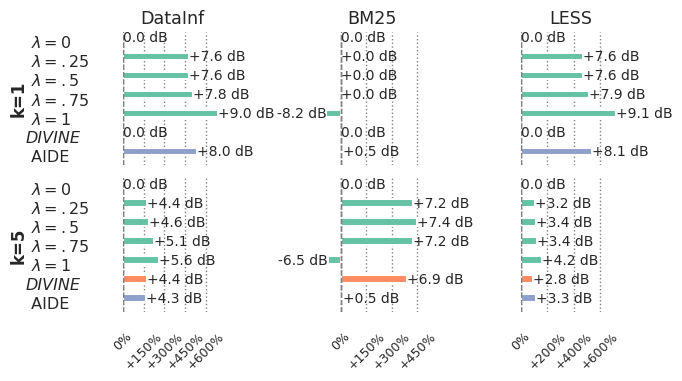

/tmp/ipykernel_1147653/913863271.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(
/root/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)


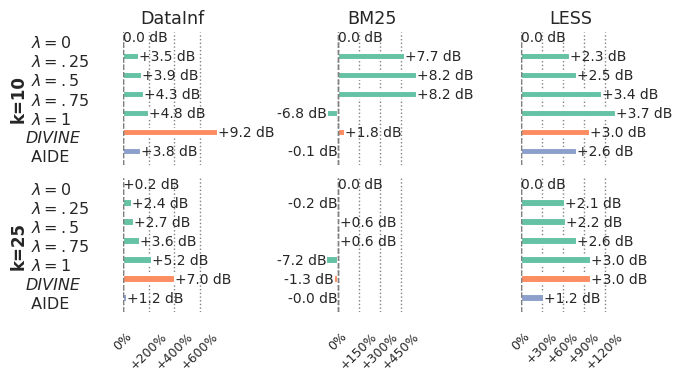

In [60]:
table["lambda"] = table["setting"].apply(get_lambda)
fff = table[(table["setting"].str.contains("largest absolute")) | (table["setting"].str.contains("AIDE"))].copy()
fff.loc[:, "sort_type"] = ~(fff["setting"].str.contains("DIVINE") | fff["setting"].str.contains("AIDE"))
fff.loc[:, "setting"] = fff["setting"].apply(rename_explanation_type)
fff["pred_gain_pct"] = (fff["pred_gain_ratio"] - 1) * 100




for name, part in [("1_5", (fff["k"] == 1) | (fff["k"] == 5)), ("10_25", (fff["k"] == 10) | (fff["k"] == 25))]:
    sns.set(style="whitegrid")
    col_order = ["DataInfEstimator: fast_implementation=True", "BM25Estimator: k1=1.5, b=0.75", "LESSEstimator: normalize=True"]
    sns.set_context("talk", font_scale=0.7)

    # Prepare grouped data
    plot_data = fff[part].groupby(["k", "estimator", "setting", "model", "lambda", "sort_type"], as_index=False)["pred_gain_pct"].mean()
    plot_data = plot_data.sort_values(by=["sort_type", "k", "lambda"], ascending=[False, True, True])

    g = sns.catplot(
        data=plot_data,
        kind="bar",
        x="pred_gain_pct",
        y="setting",
        col="estimator",
        row="k",
        col_order=col_order,
        hue="lambda",
        height=2,
        palette="Set2",
        aspect=0.7,
        orient="h",
        sharey=False,
        sharex='col',
        ci=None 
    )

    # Adjust y-axis labels
    for ax in g.axes.flatten():
        ticks = ax.get_yticks()
        labels = [
            " ".join(lbl.get_text().split(" ")[1:])
            .replace("by FL most inf.", "")
            .replace("by DIVINE most inf.", "DIVINE")
            .replace(" = ", "=")
            .replace("by", "")
            for lbl in ax.get_yticklabels()
        ]
        ax.set_yticks(ticks)
        ax.set_yticklabels(labels, ha='left')

    # Hide y labels for non-first columns
    for row_axes in g.axes:
        for ax in row_axes[1:]:
            ax.set_ylabel("")
            ax.set_yticklabels([])

    # # Hide x-axis ticks for now
    # for ax in g.axes.flatten():
    #     ax.set_xticklabels([])
    #     ax.set_xticks([])

    # Clean up column titles
    for ax, title in zip(g.axes[0, :], g.col_names):
        clean_title = title.split(":")[0].replace("Estimator", "")
        ax.set_title(clean_title)
    for row_axes in g.axes[1:]:
        for ax in row_axes:
            ax.set_title("")

    g.set_axis_labels("pred_gain Improvement (%)", "Setting")
    g.set_ylabels("")
    g.set_xlabels("")

    plt.tight_layout()
    g.fig.subplots_adjust(
        top=0.85,
        bottom=0.15,
        left=0.0,
        right=0.95,
        hspace=0.10,
        wspace=1.0
    )

    # Format x-axis and draw zero line
    for ax in g.axes.flatten():
        ax.axvline(0, color='gray', linewidth=1, linestyle='--')

    # Shorten bars visually but keep labels at original values
    for ax in g.axes.flatten():
        for container in ax.containers:
            for bar, orig_value in zip(container, container.datavalues):  # datavalues = original data
                ax.text(
                    orig_value,  # position label at original value
                    bar.get_y() + bar.get_height() / 2,
                    (lambda pct: f"{'+' if 10 * np.log10(1 + pct/100) > 0 else ''}{10 * np.log10(1 + pct/100):.1f} dB")(orig_value),                    
ha='left' if orig_value >= 0 else 'right',
                    fontsize=10,
                    clip_on=False
                )

    # Remove legend
    g._legend.remove()

    # Hide non-zero gridlines
    tol = 1e-8
    for ax in g.axes.flatten():
        for line in ax.get_xgridlines():
            x_pos = line.get_xdata()[0]
            if abs(x_pos) > tol:
                line.set_visible(False)

    sns.despine(left=True, bottom=True, right=True)

    # Adjust y label positions
    for row_axes in g.axes:
        ax = row_axes[0]
        for label in ax.get_yticklabels():
            label.set_x(-0.8)

    # Set bar colors by sort_type
    sort_type_map = fff.set_index("setting")["sort_type"].to_dict()
    for ax in g.axes.flatten():
        for container in ax.containers:
            plt.setp(container, height=0.4)
            for bar in container:
                y_label = ax.get_yticklabels()[int(bar.get_y() + bar.get_height() / 2)].get_text()
                if sort_type_map.get(y_label, False):
                    bar.set_facecolor("gray")
        for label in ax.get_yticklabels():
            if "DIVINE" in label.get_text():
                label.set_fontstyle("italic")

    # Bold k row facet labels
    for i, k_val in enumerate(sorted(fff[part]['k'].unique())):
        ax = g.axes[i, 0]
        ax.set_ylabel(f"k={k_val}", rotation=90, labelpad=5, fontsize=12, va='center', fontweight="bold")
    set2 = sns.color_palette("Set2")

    for ax in g.axes.flatten():

        # Create a single list of *all bars in order* across all containers
        all_bars = []
        for container in ax.containers:
            all_bars.extend(container)

        # Now assign colors by overall bar index
        for idx, bar in enumerate(all_bars):
            if idx < 5:
                bar.set_facecolor(set2[0])
            else:
                bar.set_facecolor(set2[(idx - 5) % (len(set2) - 1) + 1])
                    
    from matplotlib.ticker import FuncFormatter, MaxNLocator

    def pct_with_sign(x, pos):
        """Format x-axis ticks as percentage with '+' for positive values."""
        if x > 0:
            return f"+{x:.0f}%"
        else:
            return f"{x:.0f}%"

    for ax in g.axes.flatten():
        ax.axvline(0, color='gray', linewidth=1, linestyle='--')
        # Automatically choose a fixed number of ticks
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        # Use custom formatter
        ax.xaxis.set_major_formatter(FuncFormatter(pct_with_sign))
        # Enable vertical gridlines
        ax.xaxis.grid(True, linestyle=':', linewidth=1, color='gray')
        # Set tick label font size and rotation
        ax.tick_params(axis='x', labelsize=9, rotation=45)
    plt.show()
    os.makedirs("./figures/", exist_ok=True)
    filename = f"./figures/pred_gain_improvement_pct_{name}.pdf"
    g.savefig(filename, format='pdf')
